# Vertical(FieldList): interpolating from pressure to height levels

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

import earthkit.meteo.vertical.fieldlist as vertical

## Getting the data

The input is GRIB data on pressure levels plus some surface fields. We fetch the file and inspect its contents.

In [2]:
fl = ekd.from_source("sample", "tz_pl_global.grib1").to_fieldlist()
fl.head()

tz_pl_global.grib1:   0%|          | 0.00/44.2k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000,pressure,0,regular_ll
1,z,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000,pressure,0,regular_ll
2,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,850,pressure,0,regular_ll
3,z,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,850,pressure,0,regular_ll
4,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,700,pressure,0,regular_ll


We will use the following fields from the file for interpolation:

- **t** – temperature (K) on 12 pressure levels (1000, 850, 700, 500, 400, 300, 200, 150, 100, 70, 50, 30 hPa)
- **z** – geopotential (m²/s²) on the same 12 pressure levels and on the surface
  
We extract each quantity below.

In [3]:
t = fl.sel({"parameter.variable": "t", "vertical.level_type": "pressure"})
z = fl.sel({"parameter.variable": "z", "vertical.level_type": "pressure"})
zs = fl.sel({"parameter.variable": "z", "vertical.level_type": "surface"})[0]  # surface geopotential

t.head()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000,pressure,0,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,850,pressure,0,regular_ll
2,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,700,pressure,0,regular_ll
3,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,500,pressure,0,regular_ll
4,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,400,pressure,0,regular_ll


## Using interpolate_pressure_to_height_levels

### Target: geometric height above the ground

In [4]:
target_h = [1000.0, 5000.0]  # geometric height (m), above the ground

t_res = vertical.interpolate_pressure_to_height_levels(
    t,  # data on pressure levels to interpolate
    target_h,
    z,  # geopotential on the same pressure levels
    zs=zs,  # surface geopotential
    h_type="geometric",
    h_reference="ground",
    interpolation="linear",
)
t_res.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_ground_level,0,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_ground_level,0,regular_ll


In [5]:
# the first 2 values from the resulting fields
t_res.values[:, :2]

array([[269.52995877, 269.52995877],
       [249.7430541 , 249.7430541 ]])

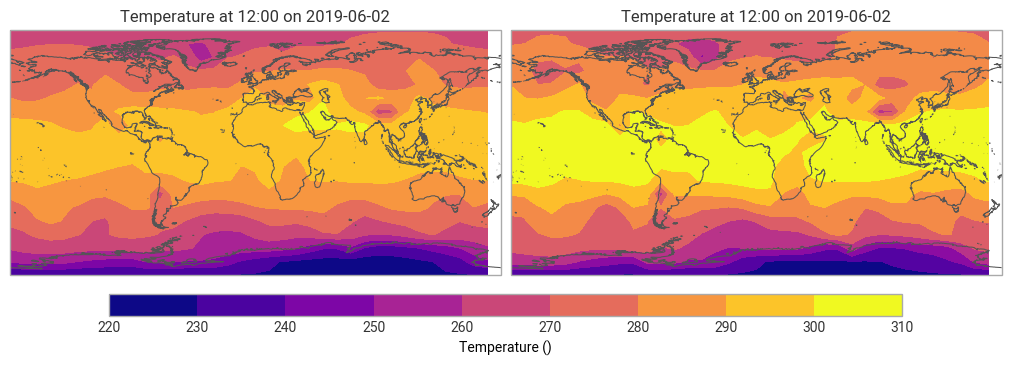

In [6]:
# plot the resulting fields
ekp.quickplot(t_res)

### Target: geometric height above sea level

In [7]:
target_h_sea = [1000.0, 5000.0]  # geometric height (m), above sea level

# zs is not used when h_reference="sea"
t_res_sea = vertical.interpolate_pressure_to_height_levels(
    t,
    target_h_sea,
    z,
    h_type="geometric",
    h_reference="sea",
    interpolation="linear",
)
t_res_sea.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_mean_sea_level,0,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_mean_sea_level,0,regular_ll


In [8]:
# the first 2 values from the resulting fields
t_res_sea.values[:, :2]

array([[269.53030875, 269.53030875],
       [249.74390207, 249.74390207]])

### Target: geopotential height above the ground

In [9]:
target_h_gp = [1000.0, 5000.0]  # geopotential height (m), above the ground

t_res_gp = vertical.interpolate_pressure_to_height_levels(
    t,
    target_h_gp,
    z,
    zs=zs,
    h_type="geopotential",
    h_reference="ground",
    interpolation="linear",
)
t_res_gp.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_ground_level,0,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_ground_level,0,regular_ll


In [10]:
# the first 2 values from the resulting fields
t_res_gp.values[:, :2]

array([[269.52940015, 269.52940015],
       [249.7167234 , 249.7167234 ]])

### Using aux levels

The lowest pressure level in the input data is 1000 hPa. In grid points where the surface pressure is significantly higher than 1000 hPa interpolation to near surface heights will result in NaNs. We can see these areas in the surface pressure plot.

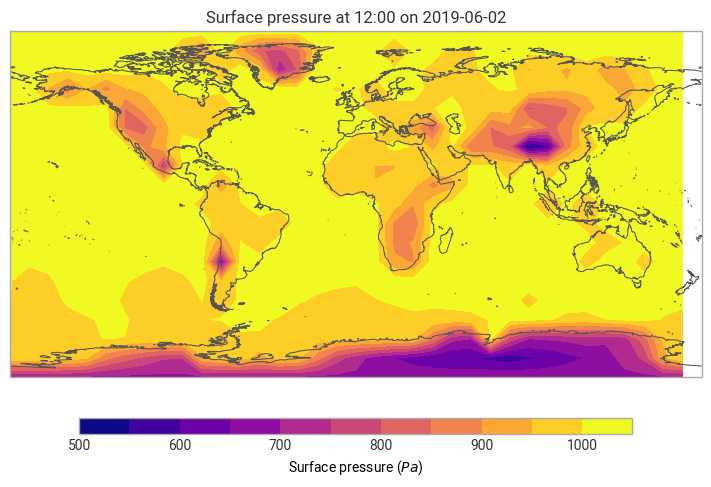

In [11]:
# extract and plot surface pressure (and convert to hPa for plotting)
sp = fl.sel({"parameter.variable": "sp"})[0] / 100.0
ekp.quickplot(sp)

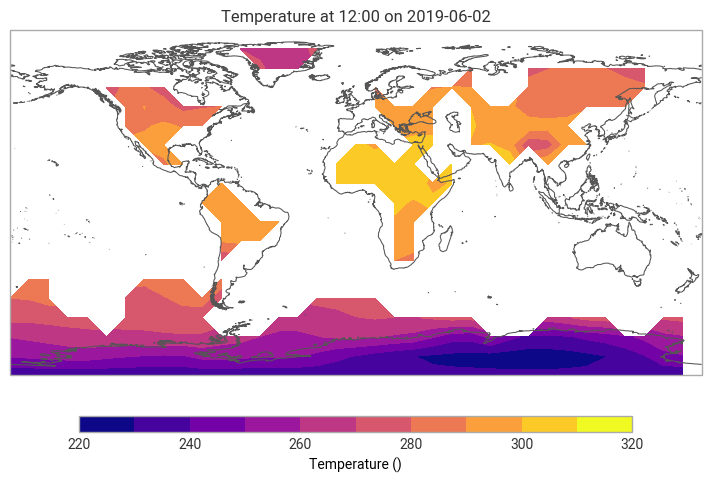

In [12]:
target_h_near_surf = [10.0]  # m above the ground

t_res_nan = vertical.interpolate_pressure_to_height_levels(
    t,
    target_h_near_surf,
    z,
    zs=zs,
    h_type="geometric",
    h_reference="ground",
    interpolation="linear",
)

# plot the resulting fields
ekp.quickplot(t_res_nan)

To overcome this problem we can supply auxiliary data via the `aux_bottom_*` kwargs. In the example below we use the 2m temperature field (available in the input data) as an auxiliary data. Note that the auxiliary data must be provided on a target coordinate level (height in this case).

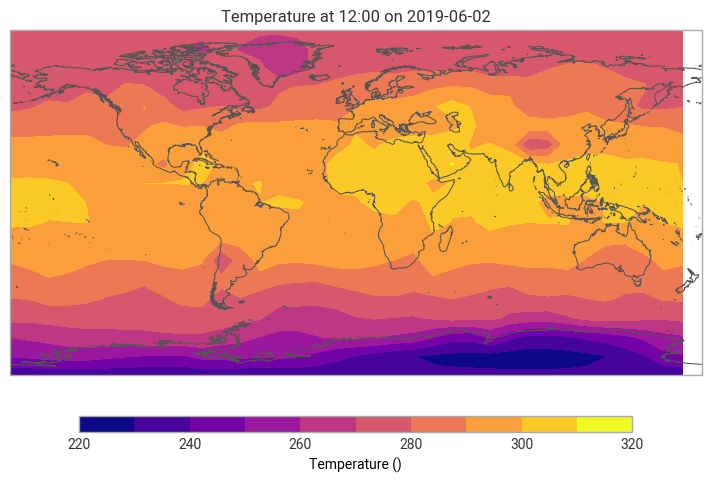

In [13]:
# extract 2m temperature field
t2 = fl.sel({"parameter.variable": "2t"})[0]

t_res_aux = vertical.interpolate_pressure_to_height_levels(
    t,
    target_h_near_surf,
    z,
    zs=zs,
    h_type="geometric",
    h_reference="ground",
    aux_bottom_h=2,  # m — height of the auxiliary level (2m)
    aux_bottom_data=t2,  # 2m temperature field
    interpolation="linear",
)

# plot the resulting fields
ekp.quickplot(t_res_aux)

### Interpolating to a height field

In [14]:
blh = ekd.from_source("sample", "blh_global.grib1").to_fieldlist()[0]
blh.ls()

blh_global.grib1:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,blh,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,0,surface,0,regular_ll


This field contains heights above ground, so we need to set ``h_reference="ground"`` for the interpolation.

In [15]:
t_res_blh = vertical.interpolate_pressure_to_height_levels(
    t,
    blh,
    z,
    zs=zs,
    h_type="geometric",
    h_reference="ground",
    interpolation="linear",
)
t_res_blh.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,637.9435,height_above_ground_level,0,regular_ll


We plot the boundary layer height and the temperature interpolated to it side by side.

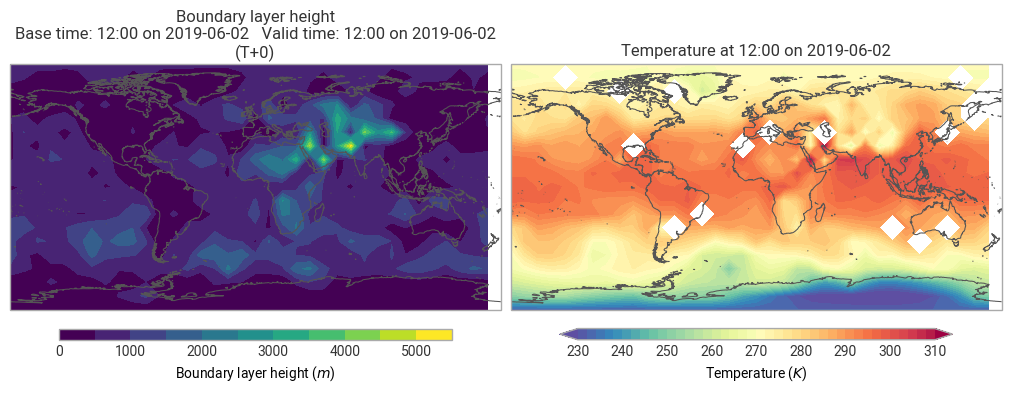

In [16]:
ekp.quickplot(ekd.FieldList.from_fields([blh, t_res_blh]))

## Writing to GRIB

In [17]:
t_res.to_target("file", "_pl_to_hl.grib")

# read back and verify
t_res_saved = ekd.from_source("file", "_pl_to_hl.grib").to_fieldlist()
t_res_saved.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000,height_above_ground_level,0,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000,height_above_ground_level,0,regular_ll


In [18]:
# the first 2 values from the saved fields
t_res_saved.values[:, :2]

array([[269.52911377, 269.52911377],
       [249.74256897, 249.74256897]])